## Hard Margin SVM (cvxpy)

Doğrusal ayrılabilir veri kümeleri için kullanılan Hard Margin SVM modelinde, kısıtlı optimizasyon problemi CVXPY kütüphanesi ile çözülür.


- **`cp.Variable(n_features)`**: Optimizasyon değişkeni olan $w$ ağırlık vektörünü tanımlamak için kullanılır ve boyutu veri kümesindeki özellik sayısına eşittir.
- **`cp.Variable()`**: Skaler bir optimizasyon değişkeni olan $b$ bias terimidir.
- **`cp.sum_squares(w)`**: Ağırlık vektörünün kareleri toplamını ($\sum w_i^2 = \|w\|_2^2$) hesaplar. Bu terim 0.5 ile çarpılarak amaç fonksiyonunu $\min \frac{1}{2}\|w\|_2^2$ oluşturur.
- **Kısıtlar (`constraints`)**: Her bir $i$ veri noktası için $y_i (w^T x_i + b) \ge 1$ koşulu liste ile tanımlanır.
- **`cp.Problem(objective, constraints)`**: Amaç fonksiyonunu ve kısıtları birleştirerek çözülecek optimizasyon problemini tanımlanır.
- **`problem.solve()`**: CVXPY arkasındaki çözücüleri tetikleyerek optimum $w$ ve $b$ değerlerini hesaplar.

In [15]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

def generate_linearly_separable_data():
    # 50 ornekli, 2 sinifli, doğrusal ayrılabilir veri seti oluşturulmaktadır
    X, y = make_blobs(n_samples=50, centers=2, random_state=42, cluster_std=1.0, n_features=2)
    # SVM matematigi icin 0 etiketleri -1 yapilmaktadir
    y = np.where(y == 0, -1, 1)
    return X, y

X, y = generate_linearly_separable_data()

def fit_hard_margin_svm(X, y):
    n_samples, n_features = X.shape
    
    # n_features boyutunda bir agirlik vektoru tanimlanmaktadir
    w = cp.Variable(n_features)     
    # Skaler (tek boyutlu) bias degiskeni tanimlanmaktadir
    b = cp.Variable()               

    # Amac fonksiyonu: ||w||^2 / 2 terimi minimize edilmektedir
    objective = cp.Minimize(0.5 * cp.sum_squares(w)) 
    
    # y_i * (w^T * x_i + b) >= 1 kisiti her veri noktasi icin kurulmaktadir
    constraints = [y[i] * (w @ X[i] + b) >= 1 for i in range(n_samples)]

    # Problem tanimlanip cozulmektedir
    problem = cp.Problem(objective, constraints)
    problem.solve()

    return w.value, b.value

w_opt, b_opt = fit_hard_margin_svm(X, y)
print("Optimize edilen w:", w_opt)
print("Optimize edilen b:", b_opt)

Optimize edilen w: [ 0.23474325 -0.23143308]
Optimize edilen b: 1.1726594075948678


### Karar Sınırı ve Eksen Dönüşümlerinin Çizimi

Karar sınırı ve marj sınırlarının grafik üzerinde doğru şekilde çizilebilmesi için eksen koordinat sınırları alınarak 2 boyutlu grid üzerinden contour çizgileri çıkarılır.

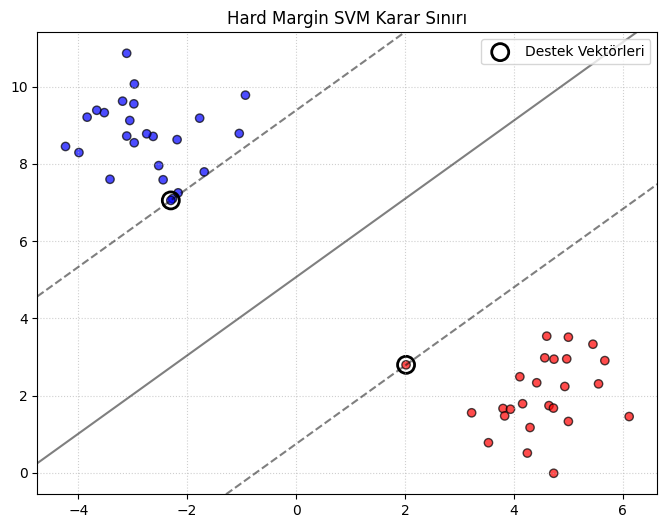

In [16]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", alpha=0.7, edgecolor="black")

ax = plt.gca()        # Mevcut cizimin eksenleri alinmaktadir
xlim = ax.get_xlim()    # x ekseni sinirlari alinmaktadir
ylim = ax.get_ylim()

xx = np.linspace(xlim[0], xlim[1], 50)
yy = np.linspace(ylim[0], ylim[1], 50)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T

# Karar fonksiyonu f(x) = w^T * x + b hesaplanmaktadir
Z = (xy @ w_opt + b_opt).reshape(XX.shape)

# Karar siniri (0) ve marjlar (-1, 1) cizilmektedir
ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5, linestyles=['--', '-', '--'])

# Destek vektorleri belirlenmektedir (y_i * f(x_i) = 1.0 kosulu)
margins = y * (X @ w_opt + b_opt)
support_vectors = X[np.isclose(margins, 1.0, atol=1e-3)]
ax.scatter(support_vectors[:, 0], support_vectors[:, 1], s=150, facecolors='none', edgecolors='k', linewidth=2, label='Destek Vektörleri')
plt.title("Hard Margin SVM Karar Sınırı")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

## Soft Margin SVM (cvxpy) ve Kod Analizi

Gürültülü veya sınıfların birbirine karıştığı durumlarda Soft Margin SVM modeli kullanılır. Bu aşamada optimizasyon modeline slack değişkenleri ($\xi_i$) dahil edilir.


- **`xi = cp.Variable(n_samples)`**: Her bir eğitim örneğinin marj sınırını ne kadar ihlal ettiğini ölçen $n$ boyutlu bir esneklik vektörü tanımlanır.
- **Amaç Fonksiyonu (`cp.sum(xi)`)**: Toplam marj ihlalleri amaç fonksiyonuna eklenerek minimize ediliyor: $\min \frac{1}{2}\|w\|^2 + C \sum \xi_i$.
- **Kısıt Yapısı**: Vektörel çarpım (`cp.multiply(y, (X @ w + b))`) kullanılarak, her bir nokta için $y_i (w^T x_i + b) \ge 1 - \xi_i$ kısıtı topluca tanımlanır. $\xi_i \ge 0$ kısıtı da sisteme eklenir.

In [17]:
# İç içe geçmiş doğrusal ayrılmayan veri seti oluşturulmaktadır
X_overlap, y_overlap = make_blobs(n_samples=100, centers=2, random_state=42, cluster_std=2.5)
y_overlap = np.where(y_overlap <= 0, -1, 1)

def fit_soft_margin_svm(X, y, C):
    n_samples, n_features = X.shape

    w = cp.Variable(n_features)
    b = cp.Variable()
    # Esneklik payi (slack variables) tanimlanmaktadir
    xi = cp.Variable(n_samples)

    # Amac fonksiyonu: ||w||^2 / 2 + C * sum(xi)
    objective = cp.Minimize(0.5 * cp.sum_squares(w) + C * cp.sum(xi))

    # Kısıtlar kurulmaktadır
    constraints = [
        cp.multiply(y, (X @ w + b)) >= 1 - xi,
        xi >= 0
    ]

    problem = cp.Problem(objective, constraints)
    problem.solve()

    return w.value, b.value, xi.value

w_soft, b_soft, xi_soft = fit_soft_margin_svm(X_overlap, y_overlap, C=1.0)
print("Soft Margin w:", w_soft)
print("Soft Margin b:", b_soft)

Soft Margin w: [ 0.92705671 -0.55829442]
Soft Margin b: 2.2101967775464537


### Slack Vektörlerinin Çizilmesi ve C Katsayısı Analizi

Karar sınırının çizilmesi ve marjı ihlal eden ($\xi_i > 0$) veri noktalarının turuncu halkalarla işaretlenerek, bu noktaların marj sınırına olan dikey uzaklıklarının kesikli çizgilerle (slack miktarı) gösterilmesi:

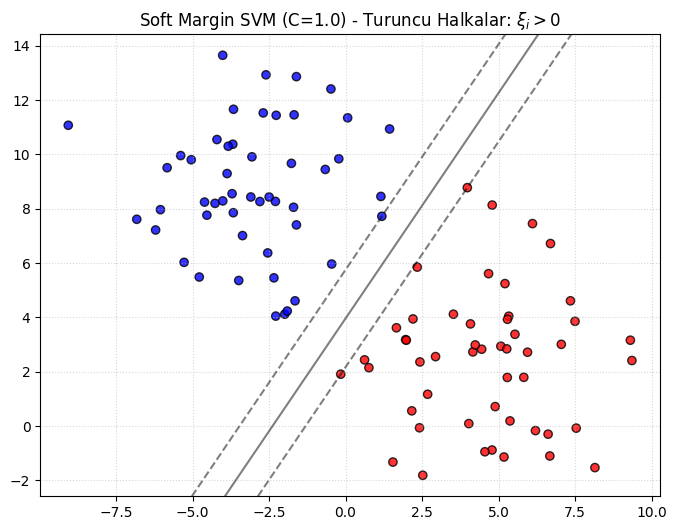

In [18]:
plt.figure(figsize=(8, 6))
plt.scatter(X_overlap[:, 0], X_overlap[:, 1], c=y_overlap, cmap='bwr', alpha=0.8, edgecolors='k')

ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()
xx = np.linspace(xlim[0], xlim[1], 50)
yy = np.linspace(ylim[0], ylim[1], 50)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = (xy @ w_soft + b_soft).reshape(XX.shape)

ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5, linestyles=['--', '-', '--'])

# Hata yapan noktalar icin slack dogruları hesaplanıp cizilmektedir
norm_w_sq = np.sum(w_soft ** 2)
for i in range(len(y_overlap)):
    if xi_soft[i] > 1e-3:
        pt = X_overlap[i]
        val = y_overlap[i] * (np.dot(w_soft, pt) + b_soft)
        if val < 1.0:
            proj = pt + y_overlap[i] * ((1.0 - val) / norm_w_sq) * w_soft
            ax.plot([pt[0], proj[0]], [pt[1], proj[1]], color='gray', linestyle=':', alpha=0.7)
            ax.scatter(pt[0], pt[1], s=100, facecolors='none', edgecolors='orange', linewidth=1.5)

# unicodeescape hatasını önlemek için LaTeX çift kaçış karakteriyle tanımlanmaktadır
plt.title("Soft Margin SVM (C=1.0) - Turuncu Halkalar: $\\xi_i > 0$")
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

## Kernel SVM (Dual Form - cvxpy) ve Kod Analizi

Doğrusal olmayan dairesel veri kümelerini sınıflandırmak amacıyla Dual Form optimizasyon problemi çözülür.


- **`polynomial_kernel(X1, X2)`**: İki matris arasındaki $(X_1 X_2^T + c)^d$ polinom çekirdek matrisini hesaplanır.
- **`np.outer(y, y)`**: Sınıf etiketlerinin dış çarpım matrisini ($Y_{ij} = y_i y_j$) oluşturulur. Örneğin:
  $$y = [-1, 1]^T \implies \text{np.outer}(y,y) = \begin{bmatrix} 1 & -1 \\ -1 & 1 \end{bmatrix}$$
- **`P = np.outer(y, y) * K`**: Formüldeki karesel terimin katsayılar matrisini oluşturulur ($P_{ij} = y_i y_j K(x_i, x_j)$).
- **`P = P + np.eye(n_samples) * 1e-5`**: Sayısal kararlılığı artırmak ve matrisin tersi alınabilirliğini garanti etmek (pozitif yarı tanımlılığı korumak) amacı eklenir.
- **`cp.quad_form(alpha, P)`**: $\alpha^T P \alpha$ karesel formunu hesaplanır.
- **Bias $b$ Hesabı**: Primal değişkenler elde edilmediği için bias terimi, bir destek vektörü $s$ seçilerek şu formülle hesaplanır:
  $$b = y_s - \sum_{j=1}^n \alpha_j y_j K(x_j, x_s)$$
- **`np.meshgrid`**: Karar sınırını çizmek amacıyla grafik alanındaki tüm $(x, y)$ kombinasyonlarını içeren 2 boyutlu koordinat matrisleri üretilir. `ravel()` ile bu matrisler düzleştirilmekte ve `np.c_` ile birleştirilerek tahmin modeline verilir.

In [19]:
from sklearn.datasets import make_circles
X_circle, y_circle = make_circles(n_samples=100, factor=0.3, noise=0.1, random_state=42)
y_circle = np.where(y_circle <= 0, -1, 1)

def polynomial_kernel(X1, X2, degree=2, c=1.0):
    return (np.dot(X1, X2.T) + c) ** degree

def fit_kernel_svm(X, y, C=1.0, degree=2):
    n_samples, n_features = X.shape
    
    # Gram/Kernel Matrisi hesaplanmaktadır
    K = polynomial_kernel(X, X, degree=degree)
    
    # Optimizasyon degiskeni alpha
    alpha = cp.Variable(n_samples)
    
    # Karesel matris P hesaplanmaktadır
    P = np.outer(y, y) * K
    # Sayisal kararlilik icin kucuk bir duzenleme eklenmektedir
    P = P + np.eye(n_samples) * 1e-5
    
    objective = cp.Minimize(0.5 * cp.quad_form(alpha, P) - cp.sum(alpha))
    constraints = [
        alpha >= 0,
        alpha <= C,
        cp.sum(cp.multiply(alpha, y)) == 0
    ]
    
    problem = cp.Problem(objective, constraints)
    problem.solve()
    
    # Ilk destek vektoru bulunup b degeri hesaplanmaktadir
    support = np.where(alpha.value > 1e-5)[0]
    sv = support[0]
    b = y[sv] - np.sum(alpha.value * y * K[:, sv])
    return alpha.value, b

alpha_opt, b_kernel = fit_kernel_svm(X_circle, y_circle, C=1.0, degree=2)
print("Bias terimi (b):", b_kernel)

Bias terimi (b): 1.4192053334548618


### Çekirdekli SVM Tahmin Fonksiyonu ve Karar Sınırı Çizimi

Grid üzerindeki her bir nokta için karar fonksiyonunun ($f(x) = \sum \alpha_i y_i K(x_i, x) + b$) hesaplanması:

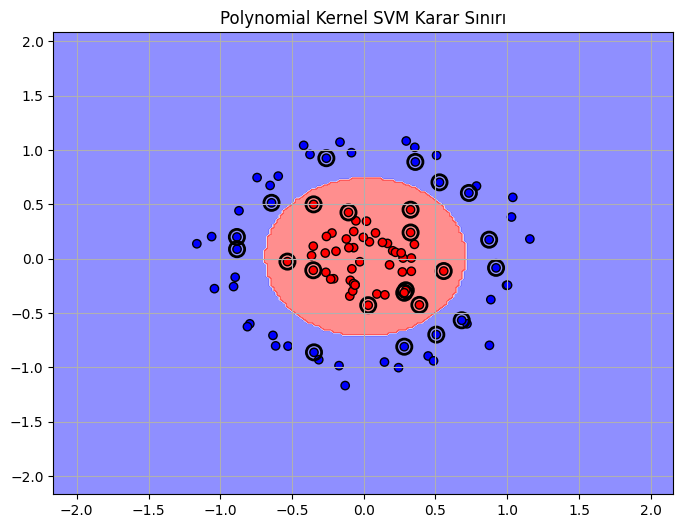

In [20]:
def predict_kernel_svm(X_train, y_train, alpha, b, X_test, degree=2):
    K = polynomial_kernel(X_train, X_test, degree=degree)
    decision = np.sum((alpha * y_train).reshape(-1, 1) * K, axis=0)
    return np.sign(decision + b)

plt.figure(figsize=(8, 6))
x_min, x_max = X_circle[:, 0].min() - 1, X_circle[:, 0].max() + 1
y_min, y_max = X_circle[:, 1].min() - 1, X_circle[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
grid_points = np.c_[xx.ravel(), yy.ravel()]

Z = predict_kernel_svm(X_circle, y_circle, alpha_opt, b_kernel, grid_points)
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.5, cmap='bwr')
plt.scatter(X_circle[:, 0], X_circle[:, 1], c=y_circle, cmap='bwr', edgecolors='k')

# Destek vektörleri
support = np.where(alpha_opt > 1e-5)[0]
plt.scatter(X_circle[support, 0], X_circle[support, 1], s=120, facecolors='none', edgecolors='k', linewidth=2)
plt.title("Polynomial Kernel SVM Karar Sınırı")
plt.grid(True)
plt.show()

## Sequential Minimal Optimization (SMO) Algoritması

SMO algoritması, dual optimizasyon problemini çözücüler kullanmadan, her adımda KKT koşullarını ihlal eden iki çarpanı analitik olarak güncelleyerek çözer.

### Kod Yapısının Analizi
- **`violates_kkt(i, E_i)`**: Bir $i$ noktası için KKT koşullarının ihlal edilip edilmediği kontrol eder:
  - $y_i E_i < -\text{tol}$ ve $\alpha_i < C$ (Hata negatif/yanlış sınıfta ve $\alpha$ artırılabilir).
  - $y_i E_i > \text{tol}$ ve $\alpha_i > 0$ (Nokta fazla güvenli tarafta ve $\alpha$ azaltılabilir).
- **`compute_bounds(i, j)`**: Güncellenecek $\alpha_j$ çarpanı için alt sınır ($L$) ve üst sınır ($H$) belirlenir. Bu sınırlar sınıfların aynı veya farklı etiketli olmasına göre değişir.
- **`update_bias(...)`**: Güncellenen $\alpha_i$ ve $\alpha_j$ katsayılarına bağlı olarak bias terimi $b$, KKT sınırlarına göre $b_1$ ve $b_2$ arasından seçilerek güncellenir.

In [21]:
from sklearn.datasets import make_blobs
X_smo, y_smo = make_blobs(n_samples=60, centers=2, random_state=42, cluster_std=1.0)
y_smo = np.where(y_smo == 0, -1, 1)

class SequentialMinimalOptimization:
    def __init__(self, C=10.0, tol=1e-3, max_passes=50):
        self.C = C
        self.tol = tol
        self.max_passes = max_passes

    def fit(self, X, y):
        self.X = X
        self.y = y
        self.n_samples, self.n_features = X.shape
        self.alpha = np.zeros(self.n_samples)
        self.b = 0.0
        # Lineer çekirdek matrisi K
        self.K = X @ X.T
        
        passes = 0
        while passes < self.max_passes:
            num_changed_alphas = 0
            for i in range(self.n_samples):
                E_i = self.compute_error(i)
                if self.violates_kkt(i, E_i):
                    # Ikinci alpha rastgele secilmektedir
                    j = self.select_second_alpha(i)
                    E_j = self.compute_error(j)
                    
                    alpha_i_old, alpha_j_old = self.alpha[i].copy(), self.alpha[j].copy()
                    L, H = self.compute_bounds(i, j)
                    if L == H: continue
                    
                    eta = 2 * self.K[i, j] - self.K[i, i] - self.K[j, j]
                    if eta >= 0: continue
                    
                    # Alpha_j guncellenmektedir
                    self.alpha[j] -= self.y[j] * (E_i - E_j) / eta
                    self.alpha[j] = np.clip(self.alpha[j], L, H)
                    
                    if abs(self.alpha[j] - alpha_j_old) < 1e-5: continue
                    
                    # Eşitliğin korunması için alpha_i güncellenmektedir
                    self.alpha[i] += self.y[i] * self.y[j] * (alpha_j_old - self.alpha[j])
                    self.alpha[i] = np.clip(self.alpha[i], 0, self.C)
                    
                    self.update_bias(i, j, alpha_i_old, alpha_j_old, E_i, E_j)
                    num_changed_alphas += 1
            if num_changed_alphas == 0: passes += 1
            else: passes = 0
        return self

    def compute_error(self, i):
        return np.sum(self.alpha * self.y * self.K[:, i]) + self.b - self.y[i]

    def violates_kkt(self, i, E_i):
        return (self.y[i] * E_i < -self.tol and self.alpha[i] < self.C) or (self.y[i] * E_i > self.tol and self.alpha[i] > 0)

    def compute_bounds(self, i, j):
        if self.y[i] != self.y[j]:
            L = max(0, self.alpha[j] - self.alpha[i])
            H = min(self.C, self.C + self.alpha[j] - self.alpha[i])
        else:
            L = max(0, self.alpha[i] + self.alpha[j] - self.C)
            H = min(self.C, self.alpha[i] + self.alpha[j])
        return L, H

    def update_bias(self, i, j, alpha_i_old, alpha_j_old, E_i, E_j):
        b1 = self.b - E_i - self.y[i] * (self.alpha[i] - alpha_i_old) * self.K[i, i] - self.y[j] * (self.alpha[j] - alpha_j_old) * self.K[i, j]
        b2 = self.b - E_j - self.y[i] * (self.alpha[i] - alpha_i_old) * self.K[i, j] - self.y[j] * (self.alpha[j] - alpha_j_old) * self.K[j, j]
        if 0 < self.alpha[i] < self.C: self.b = b1
        elif 0 < self.alpha[j] < self.C: self.b = b2
        else: self.b = (b1 + b2) / 2.0

    def select_second_alpha(self, i):
        j = i
        while j == i: j = np.random.randint(0, self.n_samples)
        return j

model_smo = SequentialMinimalOptimization(C=1.0, max_passes=30)
model_smo.fit(X_smo, y_smo)
print("SMO b bias parametresi:", model_smo.b)

SMO b bias parametresi: 1.1726451615983462
